<a href="https://colab.research.google.com/github/23f1002879/Pytorch-Computer-Vision/blob/master/notebooks/02_Dataset_Dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [29]:
train_datasets = datasets.MNIST(
    root='data',
    train=True,
    download=True
)

print('_'*50)
print(f'The length of the dataset is {len(train_datasets)}')
print('_'*50)

__________________________________________________
The length of the dataset is 60000
__________________________________________________


In [30]:
# Getting the sample image and label

image, label = train_datasets[0]
print(type(image))
print(train_datasets[0])
print(image)
print(label)

<class 'PIL.Image.Image'>
(<PIL.Image.Image image mode=L size=28x28 at 0x7C35A8E6DBE0>, 5)
<PIL.Image.Image image mode=L size=28x28 at 0x7C357DB83A10>
5


In [31]:
# We have to transform the PIL Images to tensors using transforms function since Neural Network can't directly process the PIL Image

transform = transforms.ToTensor()
train_datasets = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

image, label = train_datasets[0]

print(image.shape)

torch.Size([1, 28, 28])


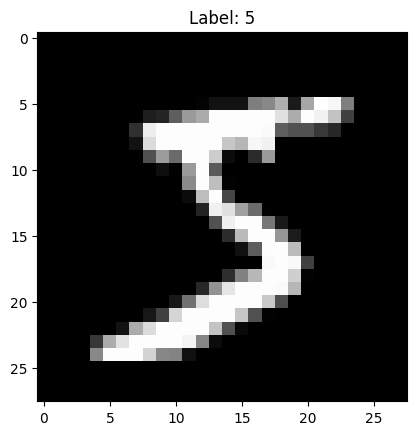

In [32]:
# Visualizing the images

plt.imshow(image.squeeze(), cmap='grey')
plt.title(f'Label: {label}')
plt.show()

In [33]:
train_loader = DataLoader(
    train_datasets,
    batch_size=32,
    shuffle=True
)

In [34]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


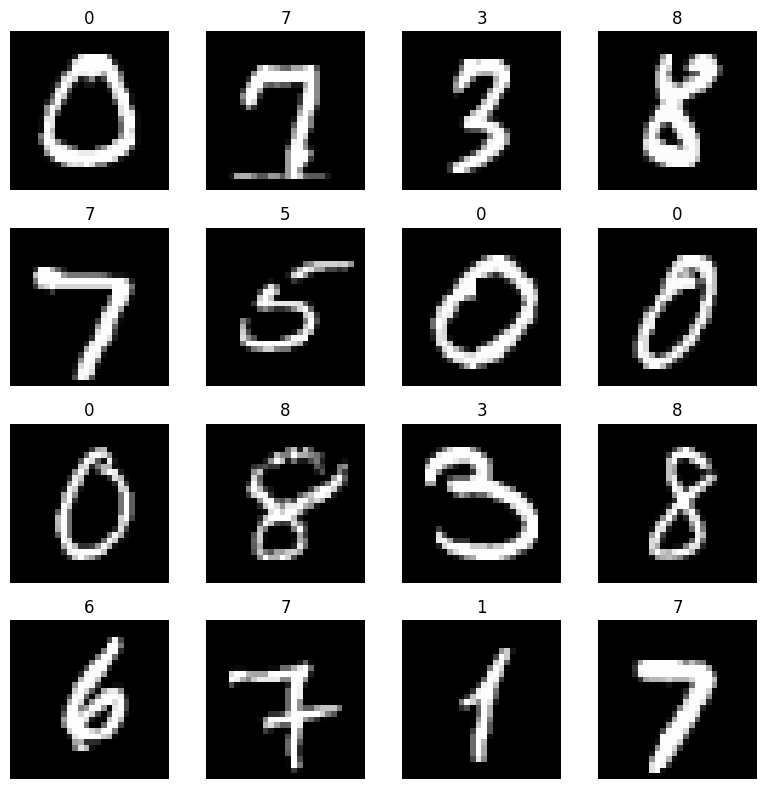

In [35]:
fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(labels[i].item())
    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# Loading Test Datasets

test_datasets = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

print('_'*50)
print(f'The length of the dataset is {len(test_datasets)}')
print('_'*50)

__________________________________________________
The length of the dataset is 10000
__________________________________________________


In [37]:
testLoader = DataLoader(
    test_datasets,
    batch_size=32,
    shuffle=False
)

# MNIST Dataset Loading Successfull

In [38]:
# Loading and Exploring the CIFAR Dataset

trainDatasets = datasets.CIFAR10(
    root='data',
    train=True,
    download=True
)

print('_'*50)
print(f'The length of the dataset is {len(trainDatasets)}')
print('_'*50)

__________________________________________________
The length of the dataset is 50000
__________________________________________________


In [39]:
print(trainDatasets[0])

image, label = trainDatasets[0]

print(image)
print(label)
print(type(image))

# Since it is a PIL Image, it needs to be transform before giving it into the neural network.

(<PIL.Image.Image image mode=RGB size=32x32 at 0x7C357DB83FB0>, 6)
<PIL.Image.Image image mode=RGB size=32x32 at 0x7C357DB83800>
6
<class 'PIL.Image.Image'>


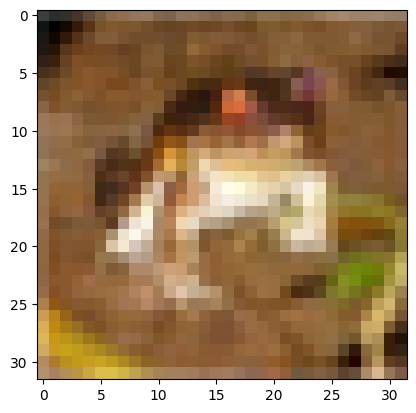

In [44]:
transform = transforms.ToTensor()

# again loading the dataset with the transformed image

trainDatasets = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=transform
)

image, label = trainDatasets[0]

plt.imshow(image.permute(1,2,0))
plt.show()

In [46]:
trainLoader = DataLoader(
    trainDatasets,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

testDatasets = datasets.CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=transform
)

testLoader = DataLoader(
    testDatasets,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [50]:
images, labels = next(iter(trainLoader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32])
